In [16]:
import pandas as pd

fct = pd.read_parquet("data/fct_lap.parquet")
dim_driver = pd.read_parquet("data/dim_driver.parquet")
dim_session = pd.read_parquet("data/dim_session.parquet")
dim_team = pd.read_parquet("data/dim_team.parquet")
dim_compound = pd.read_parquet("data/dim_compound.parquet")

In [17]:
print(fct.dtypes)

time                    timedelta64[ns]
lap_time                timedelta64[ns]
lap_number                        Int64
stint                             Int64
pit_out_time            timedelta64[ns]
pit_in_time             timedelta64[ns]
sector1_time            timedelta64[ns]
sector2_time            timedelta64[ns]
sector3_time            timedelta64[ns]
sector1_session_time    timedelta64[ns]
sector2_session_time    timedelta64[ns]
sector3_session_time    timedelta64[ns]
speed_i1                        float64
speed_i2                        float64
speed_fl                        float64
speed_st                        float64
is_personal_best                 object
tyre_life                         Int64
fresh_tyre                         bool
lap_start_time          timedelta64[ns]
lap_start_date           datetime64[ns]
track_status                     object
position                          Int64
deleted                          object
deleted_reason                   object


In [18]:
pace = fct[fct["is_pace_lap"]].copy()
pace['lap_time_s'] = pace["lap_time"].dt.total_seconds()
print(len(pace))
pace

4902


,time,lap_time,lap_number,stint,pit_out_time,pit_in_time,sector1_time,sector2_time,sector3_time,sector1_session_time,...,team_key,driver_key,compound_key,session_key,is_first_lap,is_in_lap,is_out_lap,is_not_green,is_pace_lap,lap_time_s
1,0 days 00:59:58.605000,0 days 00:01:23.412000,2,1,NaT,NaT,0 days 00:00:29.364000,0 days 00:00:32.600000,0 days 00:00:21.448000,0 days 00:59:04.573000,...,1,3,2,1,False,False,False,False,True,83.412
3,0 days 01:02:44.094000,0 days 00:01:22.787000,4,1,NaT,NaT,0 days 00:00:28.845000,0 days 00:00:32.551000,0 days 00:00:21.391000,0 days 01:01:50.168000,...,1,3,2,1,False,False,False,False,True,82.787
4,0 days 01:04:06.632000,0 days 00:01:22.538000,5,1,NaT,NaT,0 days 00:00:28.826000,0 days 00:00:32.294000,0 days 00:00:21.418000,0 days 01:03:12.936000,...,1,3,2,1,False,False,False,False,True,82.538
6,0 days 01:06:57.942000,0 days 00:01:22.981000,7,1,NaT,NaT,0 days 00:00:28.977000,0 days 00:00:32.542000,0 days 00:00:21.462000,0 days 01:06:03.954000,...,1,3,2,1,False,False,False,False,True,82.981
7,0 days 01:08:20.952000,0 days 00:01:23.010000,8,1,NaT,NaT,0 days 00:00:28.925000,0 days 00:00:32.704000,0 days 00:00:21.381000,0 days 01:07:26.883000,...,1,3,2,1,False,False,False,False,True,83.010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5618,0 days 02:18:45.302000,0 days 00:01:28.723000,53,3,NaT,NaT,0 days 00:00:17.776000,0 days 00:00:38.507000,0 days 00:00:32.440000,0 days 02:17:34.429000,...,2,16,2,5,False,False,False,False,True,88.723
5619,0 days 02:20:13.982000,0 days 00:01:28.680000,54,3,NaT,NaT,0 days 00:00:17.875000,0 days 00:00:38.411000,0 days 00:00:32.394000,0 days 02:19:03.251000,...,2,16,2,5,False,False,False,False,True,88.680
5620,0 days 02:21:42.552000,0 days 00:01:28.570000,55,3,NaT,NaT,0 days 00:00:17.709000,0 days 00:00:38.457000,0 days 00:00:32.404000,0 days 02:20:31.765000,...,2,16,2,5,False,False,False,False,True,88.570
5621,0 days 02:23:11.492000,0 days 00:01:28.940000,56,3,NaT,NaT,0 days 00:00:17.865000,0 days 00:00:38.471000,0 days 00:00:32.604000,0 days 02:22:00.491000,...,2,16,2,5,False,False,False,False,True,88.940


In [19]:
pace.groupby(['driver_key', 'session_key'])["lap_time_s"].std()

driver_key  session_key
1           1              0.612838
            2              0.575727
            3              1.069451
            4              1.119236
            5              1.050204
                             ...   
20          1                   NaN
            2              0.573979
            3              0.961474
            4              1.473241
            5              0.859495
Name: lap_time_s, Length: 96, dtype: float64

In [20]:
counts = pace.groupby(["driver_key", "session_key"])["lap_time_s"].count()
print(counts.sort_values().head(10))

driver_key  session_key
20          1               1
19          4               5
            1              21
8           2              24
12          3              27
18          1              28
4           4              32
9           3              42
20          3              42
16          3              42
Name: lap_time_s, dtype: int64


<Axes: xlabel='count', ylabel='std'>

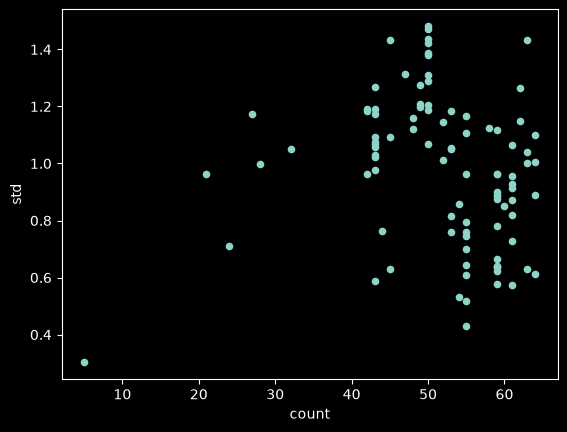

In [21]:
stats = pace.groupby(["driver_key", "session_key"])["lap_time_s"].agg(["count", "std"]).reset_index()
stats.plot.scatter(x="count", y="std")

In [22]:
print((stats["count"] < 40).sum())
print((stats["count"] < 30).sum())

7
6


In [23]:
stats = pace.groupby(["driver_key", "session_key"])["lap_time_s"].agg(["count", "std"]).reset_index()
stats = stats[stats["count"] >= 40]
print(len(stats))

89


In [24]:
stats = stats.merge(dim_driver[["driver_key","driver_code"]], on="driver_key", how="left")
stats = stats.merge(dim_session[["session_key","event_name"]], on="session_key", how="left")

stats

,driver_key,session_key,count,std,driver_code,event_name
0,1,1,64,0.612838,NOR,Mexico City Grand Prix
1,1,2,59,0.575727,NOR,São Paulo Grand Prix
2,1,3,43,1.069451,NOR,Las Vegas Grand Prix
3,1,4,48,1.119236,NOR,Qatar Grand Prix
4,1,5,53,1.050204,NOR,Abu Dhabi Grand Prix
...,...,...,...,...,...,...
84,19,5,53,1.184147,HUL,Abu Dhabi Grand Prix
85,20,2,61,0.573979,LAW,São Paulo Grand Prix
86,20,3,42,0.961474,LAW,Las Vegas Grand Prix
87,20,4,50,1.473241,LAW,Qatar Grand Prix
